<div style="background: linear-gradient(135deg, #1a3a5c 0%, #2d6a9f 100%); padding: 40px 32px 32px 32px; border-radius: 12px; margin-bottom: 8px;">
  <h1 style="color: #ffffff; font-size: 2.0em; margin: 0 0 6px 0; font-family: 'Segoe UI', sans-serif; font-weight: 700;">
    Week 6, Lesson 12 -- Model Optimization
  </h1>
  <h2 style="color: #a8d4f5; font-size: 1.2em; margin: 0 0 18px 0; font-family: 'Segoe UI', sans-serif; font-weight: 400;">
    Systematic Hyperparameter Tuning and Explainable AI
  </h2>
  <hr style="border: 1px solid rgba(255,255,255,0.25); margin: 16px 0;">
  <table style="color: #cce4ff; font-family: 'Segoe UI', sans-serif; font-size: 0.95em;">
    <tr>
      <td style="padding: 3px 24px 3px 0;"><strong>Week:</strong></td><td>6 (Lesson 12) -- Model Optimization</td>
      <td style="padding: 3px 24px 3px 32px;"><strong>Duration:</strong></td><td>40 Minutes</td>
    </tr>
    <tr>
      <td style="padding: 3px 24px 3px 0;"><strong>Track:</strong></td><td>Petroleum Engineers &amp; Geoscientists</td>
      <td style="padding: 3px 24px 3px 32px;"><strong>Audience:</strong></td><td>Engineers &amp; Geoscientists</td>
    </tr>
    <tr>
      <td style="padding: 3px 24px 3px 0;"><strong>Instructor:</strong></td><td>Dr. Daniel Wamriew</td>
      <td style="padding: 3px 24px 3px 32px;"><strong>Contact:</strong></td><td>wamriewdan@gmail.com</td>
    </tr>
  </table>
</div>


<div style="background: #e8f5e9; border-left: 5px solid #2ca87f; padding: 14px 20px; border-radius: 0 8px 8px 0; margin: 12px 0;">

### How to Use This Notebook

Work through this notebook **from top to bottom**, pressing **Shift + Enter** on each cell to run it.

- **Code cells** contain Python -- run them and read the output carefully.
- **Markdown cells** (white background) contain explanations -- read before running the next cell.
- **Student Activity** cells are marked with `Activity` -- complete these before moving on.
- **Homework** cells are marked with `Homework` -- complete after the session.
- You need **`well_log_data.csv`** in the course `data` folder.
- Install scikit-learn once if needed: **`pip install scikit-learn`**
- The grid search cell takes **10-20 seconds** to run -- this is normal.

</div>


---
## Table of Contents

1. [Where We Are: Back to Supervised Learning](#1-where-we-are-back-to-supervised-learning)
2. [From Manual Tuning to GridSearchCV](#2-from-manual-tuning-to-gridsearchcv)
3. [Prepare the Data](#3-prepare-the-data)
4. [Grid Search with Cross-Validation](#4-grid-search-with-cross-validation)
5. [Evaluate the Tuned Model](#5-evaluate-the-tuned-model)
6. [Explainable AI: Permutation Importance](#6-explainable-ai-permutation-importance)
7. [Partial Dependence Plots](#7-partial-dependence-plots)
8. [Student Activity](#8-student-activity)
9. [Recap & Homework](#9-recap-homework)


---
## 1. Where We Are: Back to Supervised Learning

<div style="background: #f0f7ff; border-left: 5px solid #2d6a9f; padding: 16px 20px; border-radius: 0 8px 8px 0; margin: 12px 0;">

Lesson 11 was a deliberate detour. You had **no labels** and used K-Means and PCA to discover structure in
well logs on your own -- useful for a brand-new well with no formation picks yet.

Today we have labels again (`Formation`, from Lessons 9-10), so we return to **supervised learning**.
But we are not starting a new topic -- we are finishing the workflow you started in Lesson 8:

```
Lesson 8-9:  Build a model                (baseline)
Lesson 10:   Validate it properly          (cross-validation, Random Forest)
Lesson 12:   Tune it systematically        (this lesson)
             ...and explain what it relies on  (this lesson)
```

Unsupervised learning is a tool you reach for **when you lack labels**. The moment you have labels again,
the supervised workflow above is what turns a working model into one you can tune with confidence and
defend in a technical review. That is the rest of today's lesson.

</div>


---
## 2. From Manual Tuning to GridSearchCV

<div style="background: #f0f7ff; border-left: 5px solid #2d6a9f; padding: 16px 20px; border-radius: 0 8px 8px 0; margin: 12px 0;">

In Lesson 10 you tuned a Random Forest with a hand-written `for` loop over `n_estimators` and `max_depth`.
That does not scale well to a third or fourth hyperparameter, and there is no automatic bookkeeping of the winner.

**`GridSearchCV`** does this systematically: give it a dictionary of hyperparameter values, and it tries
**every combination**, scoring each one with cross-validation, and keeps the best.

</div>

<div style="background: #fff8e1; border-left: 5px solid #e0a800; padding: 14px 20px; border-radius: 0 8px 8px 0; margin: 12px 0;">

**A note on `RandomizedSearchCV`:** for large hyperparameter spaces, trying every combination becomes too
slow. `RandomizedSearchCV` samples a fixed number of random combinations instead of all of them -- much
faster, usually close to as good. We will not run it live in class; instead **Homework Task 1** has you
run it yourself and decide, with evidence, whether it would have been good enough to deploy.

</div>


---
## 3. Prepare the Data

Same `well_log_data.csv`, same five log features and `Formation` target as Lessons 9-10, so results stay comparable.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

# Load and clean data
df = pd.read_csv("well_log_data.csv")
log_cols = ["GR_API", "NPHI_frac", "RHOB_gcc", "RT_ohmm", "SW_frac"]
df[log_cols] = df.groupby("Well_ID")[log_cols].ffill()
df[log_cols] = df.groupby("Well_ID")[log_cols].bfill()

feature_cols = ["GR_API", "NPHI_frac", "RHOB_gcc", "RT_ohmm", "SW_frac"]
class_order = ["Shale_Cap", "Reservoir_1", "Transition", "Reservoir_2", "Basement"]

X = df[feature_cols]
y = df["Formation"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"Training rows: {len(X_train)}   Test rows: {len(X_test)}")


Training rows: 576   Test rows: 144


---
## 4. Grid Search with Cross-Validation

We tune three hyperparameters at once and let `GridSearchCV` find the best combination.
The **Lesson 10 baseline** (`n_estimators=100, max_depth=5`) is included in the grid, so this search can
only match or beat it -- never do worse.


In [2]:
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 8, None],
    "min_samples_leaf": [1, 3, 5]
}
n_combinations = 3 * 4 * 3
print(f"Testing {n_combinations} combinations x 5 folds = {n_combinations*5} model fits...")

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, class_weight="balanced"),
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print(f"Best parameters : {grid_search.best_params_}")
print(f"Best CV accuracy: {grid_search.best_score_:.3f}")


Testing 36 combinations x 5 folds = 180 model fits...
Best parameters : {'max_depth': 8, 'min_samples_leaf': 3, 'n_estimators': 100}
Best CV accuracy: 0.833


---
## 5. Evaluate the Tuned Model

We take `grid_search`'s best model and evaluate it once on the held-out test set.


In [3]:
best_model = grid_search.best_estimator_
test_pred = best_model.predict(X_test)
test_acc = accuracy_score(y_test, test_pred)

print(f"Tuned Random Forest test accuracy: {test_acc:.3f}")
print("\nClassification report:")
print(classification_report(y_test, test_pred, labels=class_order, target_names=class_order))


Tuned Random Forest test accuracy: 0.819

Classification report:
              precision    recall  f1-score   support

   Shale_Cap       1.00      1.00      1.00        19
 Reservoir_1       0.79      0.62      0.70        48
  Transition       1.00      1.00      1.00        16
 Reservoir_2       0.62      0.79      0.70        38
    Basement       1.00      1.00      1.00        23

    accuracy                           0.82       144
   macro avg       0.88      0.88      0.88       144
weighted avg       0.83      0.82      0.82       144



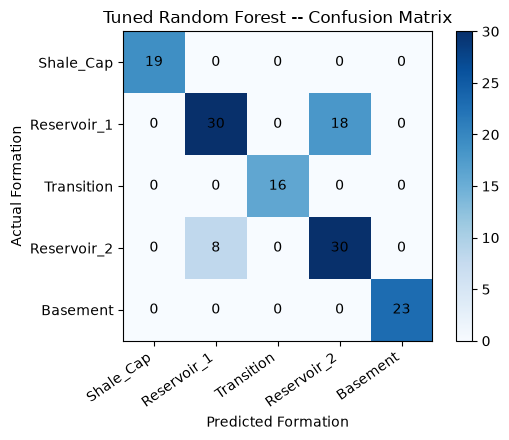

In [4]:
# Confusion matrix for the tuned model
cm = confusion_matrix(y_test, test_pred, labels=class_order)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(class_order)))
ax.set_yticks(range(len(class_order)))
ax.set_xticklabels(class_order, rotation=35, ha="right")
ax.set_yticklabels(class_order)
ax.set_xlabel("Predicted Formation")
ax.set_ylabel("Actual Formation")
ax.set_title("Tuned Random Forest -- Confusion Matrix")
for i in range(len(class_order)):
    for j in range(len(class_order)):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="black")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


---
## 6. Explainable AI: Permutation Importance

<div style="background: #fff8e1; border-left: 5px solid #e0a800; padding: 14px 20px; border-radius: 0 8px 8px 0; margin: 12px 0;">

A tuned model is not automatically one you can defend. Lesson 10's `feature_importances_` measures
importance **during training** and can mislead when features are correlated (e.g. `RHOB_gcc` and `NPHI_frac`
both carry porosity information).

**Permutation importance** measures it on the **test set** instead: shuffle one feature column, see how much
accuracy drops, repeat for every feature. A bigger drop means the model relies on that feature more.

</div>


In [5]:
perm_result = permutation_importance(
    best_model, X_test, y_test, n_repeats=30, random_state=42, scoring="accuracy"
)
perm_df = pd.DataFrame({
    "feature": feature_cols,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std
}).sort_values("importance_mean", ascending=False).reset_index(drop=True)
perm_df


,feature,importance_mean,importance_std
0,SW_frac,0.298843,0.037029
1,RT_ohmm,0.131481,0.027070
2,GR_API,0.037500,0.019444
3,NPHI_frac,0.036806,0.016835
4,RHOB_gcc,0.035648,0.013021


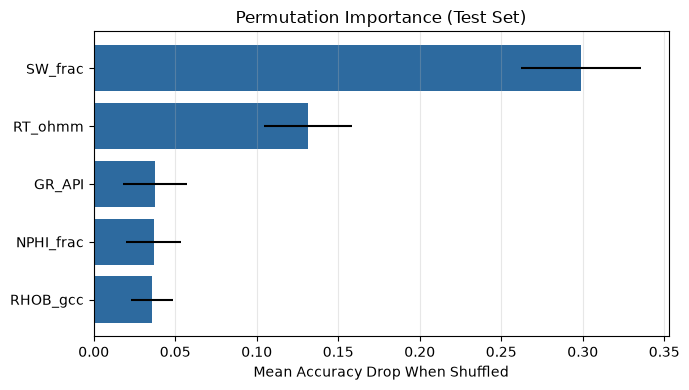

In [6]:
perm_sorted = perm_df.sort_values("importance_mean")
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(perm_sorted["feature"], perm_sorted["importance_mean"],
        xerr=perm_sorted["importance_std"], color="#2d6a9f")
ax.set_title("Permutation Importance (Test Set)")
ax.set_xlabel("Mean Accuracy Drop When Shuffled")
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()


> **Compare to Lesson 10:** if this ranking mostly agrees with the training-based `feature_importances_`
> ranking from Lesson 10, that is a good sign. Where they disagree, trust this one -- it is measured on
> data the model never trained on.


---
## 7. Partial Dependence Plots

Importance tells you **how much** a feature matters. A **Partial Dependence Plot (PDP)** shows **how** --
the model's average predicted probability of a class as one feature varies, holding the others fixed.

We check `P(Formation = Reservoir_1)` against `GR_API` and `SW_frac`, the two features most tied to
hydrocarbon-bearing rock.


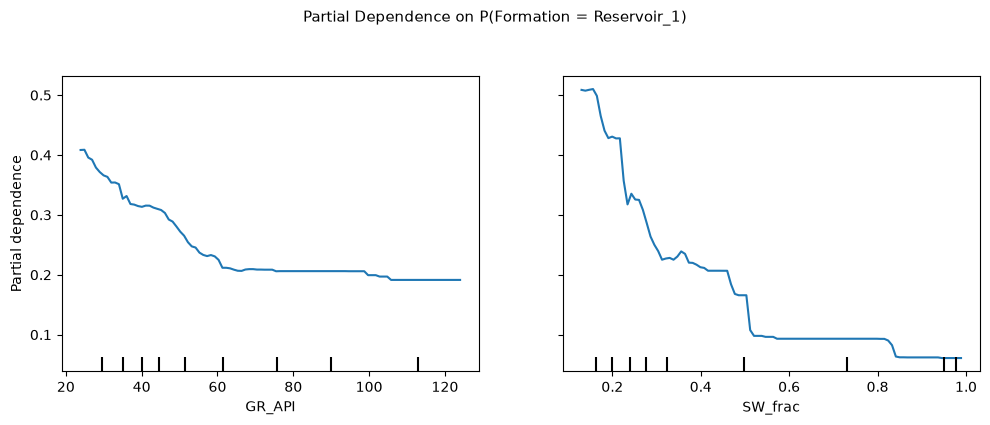

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
PartialDependenceDisplay.from_estimator(
    best_model, X_train, features=["GR_API", "SW_frac"], target="Reservoir_1", ax=ax
)
fig.suptitle("Partial Dependence on P(Formation = Reservoir_1)", fontsize=11, y=1.05)
plt.tight_layout()
plt.show()


> A downward-sloping curve means higher values of that feature make `Reservoir_1` **less** likely.
> Rising `SW_frac` (more water) should push the curve down -- check that it does. If a curve contradicts
> known petrophysics, investigate before trusting the model.


---
## 8. Student Activity

<div style="background: #fff3cd; border-left: 5px solid #ffc107; padding: 16px 20px; border-radius: 0 8px 8px 0; margin: 12px 0;">

### Activity: Add One Hyperparameter

Add `max_features` to `param_grid` from Section 4, trying `["sqrt", "log2"]`. Rerun `GridSearchCV`.

- New `best_params_`:
- New `best_score_`:
- Did accuracy improve? By how much?
- How many total combinations did this add, and how much longer did the search take?

</div>


In [10]:
# Activity -- add max_features to the grid and rerun GridSearchCV
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 8, None],
    "min_samples_leaf": [1, 3, 5],
    "max_features": ["sqrt", "log2", None]
}
n_combinations = 3 * 4 * 3
print(f"Testing {n_combinations} combinations x 5 folds = {n_combinations*5} model fits...")

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, class_weight="balanced"),
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print(f"New Best parameters : {grid_search.best_params_}")
print(f"New Best CV accuracy: {grid_search.best_score_:.3f}")



Testing 36 combinations x 5 folds = 180 model fits...
New Best parameters : {'max_depth': 5, 'max_features': None, 'min_samples_leaf': 3, 'n_estimators': 50}
New Best CV accuracy: 0.835


---
## 9. Recap & Homework

<div style="background: #e8f5e9; border-left: 5px solid #2ca87f; padding: 16px 20px; border-radius: 0 8px 8px 0; margin: 12px 0;">

### What You Learned

| Concept | Meaning |
|---------|---------|
| GridSearchCV | Exhaustive search over every hyperparameter combination, scored with cross-validation |
| RandomizedSearchCV | Samples a fixed number of random combinations -- faster on large spaces |
| Permutation importance | Test-set importance found by shuffling one feature at a time |
| Partial dependence plot | How a predicted probability changes as one feature varies |

A tuned model is only useful if you can also explain what it depends on. This closes out classical ML --
next lesson starts Deep Learning.

</div>


### Homework

**Task 1 -- GridSearchCV vs RandomizedSearchCV: Which Would You Deploy?**

Run `RandomizedSearchCV` with the distributions below, `n_iter=15`, and the same `cv`:

```python
from scipy.stats import randint
param_distributions = {
    "n_estimators": randint(50, 300),
    "max_depth": randint(2, 15),
    "min_samples_leaf": randint(1, 10)
}
```

Fit it, then compare against today's `grid_search`:

1. `best_score_` (CV accuracy) for both
2. Test-set accuracy for both (`.best_estimator_.predict(X_test)`)
3. Wall-clock time for both (use `time.time()` before/after `.fit()`)

Write three sentences: which model would you actually deploy, and was the exhaustive grid search worth
its extra time compared to the random search?

**Task 2 -- Permutation Importance on the Training Set**

Recompute permutation importance using `X_train, y_train` instead of the test set. Compare the ranking to
Section 6. Which one do you trust more, and why?

**Task 3 (Engineering) -- Partial Dependence for a Different Class**

Plot partial dependence of `RHOB_gcc` and `NPHI_frac` against `P(Formation = Basement)`. Do the curve
directions make petrophysical sense for a dense, low-porosity basement zone? Explain in two sentences.


In [18]:
# Homework Task 1 -- GridSearchCV vs RandomizedSearchCV
# Hint: from scipy.stats import randint; import time

param_distributions = {
    "n_estimators": randint(50, 300),
    "max_depth": randint(2, 15),
    "min_samples_leaf": randint(1, 10)
}

randomized_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42, class_weight="balanced"),
    param_distributions=param_distributions,
    cv=cv,
    n_iter=15,
    scoring="accuracy"
)

start = time()
randomized_search.fit(X_train, y_train)
elapsed = time() - start

print(f"Best parameters : {randomized_search.best_params_}")
print(f"Best CV accuracy: {randomized_search.best_score_:.3f}")
print(f"RandomizedSearchCV test accuracy: {accuracy_score(y_test, randomized_search.predict(X_test)):.3f}")
print(f"Time taken: {elapsed:.2f} seconds")



Best parameters : {'max_depth': 10, 'min_samples_leaf': 7, 'n_estimators': 287}
Best CV accuracy: 0.825
RandomizedSearchCV test accuracy: 0.826
Time taken: 49.57 seconds


In [17]:
# Homework Task 2 -- Permutation Importance on the Training Set
# Hint: permutation_importance(best_model, X_train, y_train, n_repeats=30, random_state=42)
perm_result = permutation_importance(
    best_model, X_test, y_test, n_repeats=30, random_state=42
)
perm_df = pd.DataFrame({
    "feature": feature_cols,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std
}).sort_values("importance_mean", ascending=False).reset_index(drop=True)
perm_df


,feature,importance_mean,importance_std
0,SW_frac,0.298843,0.037029
1,RT_ohmm,0.131481,0.027070
2,GR_API,0.037500,0.019444
3,NPHI_frac,0.036806,0.016835
4,RHOB_gcc,0.035648,0.013021


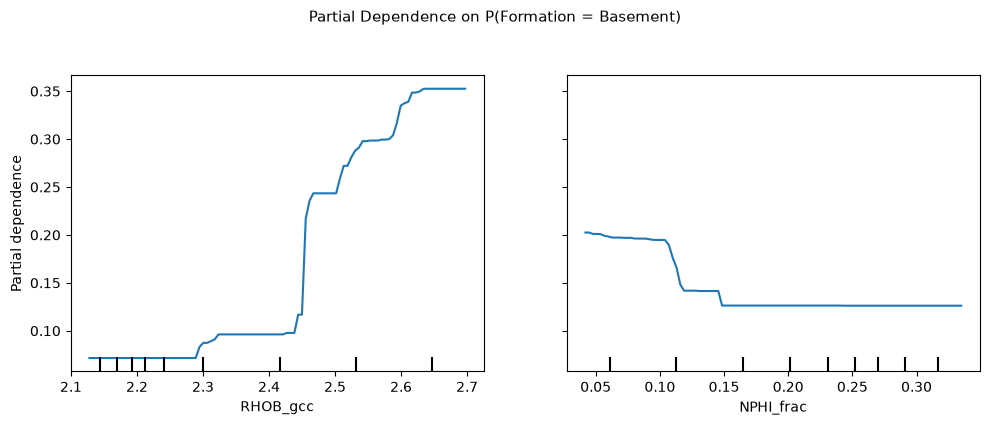

In [19]:
# Homework Task 3 (Engineering) -- Partial Dependence for a Different Class
# Hint: PartialDependenceDisplay.from_estimator(best_model, X_train, features=[...], target="Basement")
fig, ax = plt.subplots(figsize=(10, 4))
PartialDependenceDisplay.from_estimator(
    best_model, X_train, features=["RHOB_gcc", "NPHI_frac"], target="Basement", ax=ax
)
fig.suptitle("Partial Dependence on P(Formation = Basement)", fontsize=11, y=1.05)
plt.tight_layout()
plt.show()


<div style="background: #1a3a5c; color: white; padding: 22px 26px; border-radius: 10px; margin-top: 18px;">
  <h3 style="margin-top: 0; color: #ffffff;">Lesson Complete</h3>
  <p style="margin-bottom: 0; color: #d8ecff;">
    You have replaced hand-written tuning loops with systematic search, and moved beyond a single
    importance score to test-set-based, defensible explanations of model behavior.
    This closes out classical machine learning for this course.
    Next: <strong>Lesson 13 -- Neural Networks Intuition</strong>, the start of Deep Learning.
  </p>
</div>
